## 1. 図の提案

### 案A（優先1）: 時系列レジーム図（価格・スプレッド・注文フロー）
- 目的: いつ市場構造が変わったかを時系列で把握
- 構成:
  1) `mid_price` と rolling mean
  2) `bid_ask_spread_bps` と rolling mean（流動性悪化イベント線）
  3) `order_imbalance` と rolling mean（注文フロー偏り）
- 強み: 変化点と要因候補（流動性かフローか）を同じ時間軸で確認しやすい

### 案B（優先2）: 注文フロー偏りと短期価格反応の散布図
- 目的: フロー偏りが価格インパクトに繋がるかを検証
- 構成: `order_imbalance`（横軸）vs 将来5ステップ先リターンbps（縦軸）
  色=`bid_ask_spread_bps`、点サイズ=`trade_size`
- 強み: 「偏りがあるときだけ動くか」「流動性が薄い時だけ効くか」を同時に見られる

### 案C（候補3）: 流動性ストレスの時間帯比較
- 目的: どの時間帯に流動性悪化が集中するかを把握
- 構成: 時間帯ごとの平均 spread / depth / |imbalance|
- 強み: 監視すべき時間帯の特定に有効

### 優先順位の理由
- 案Aを優先: まず時間軸で何が起きたかの全体像を掴むことが、後段の関係分析の前提になるため
- 案Bを次点: 実務で重要な「注文フロー偏り -> 価格反応」を直接検証できるため

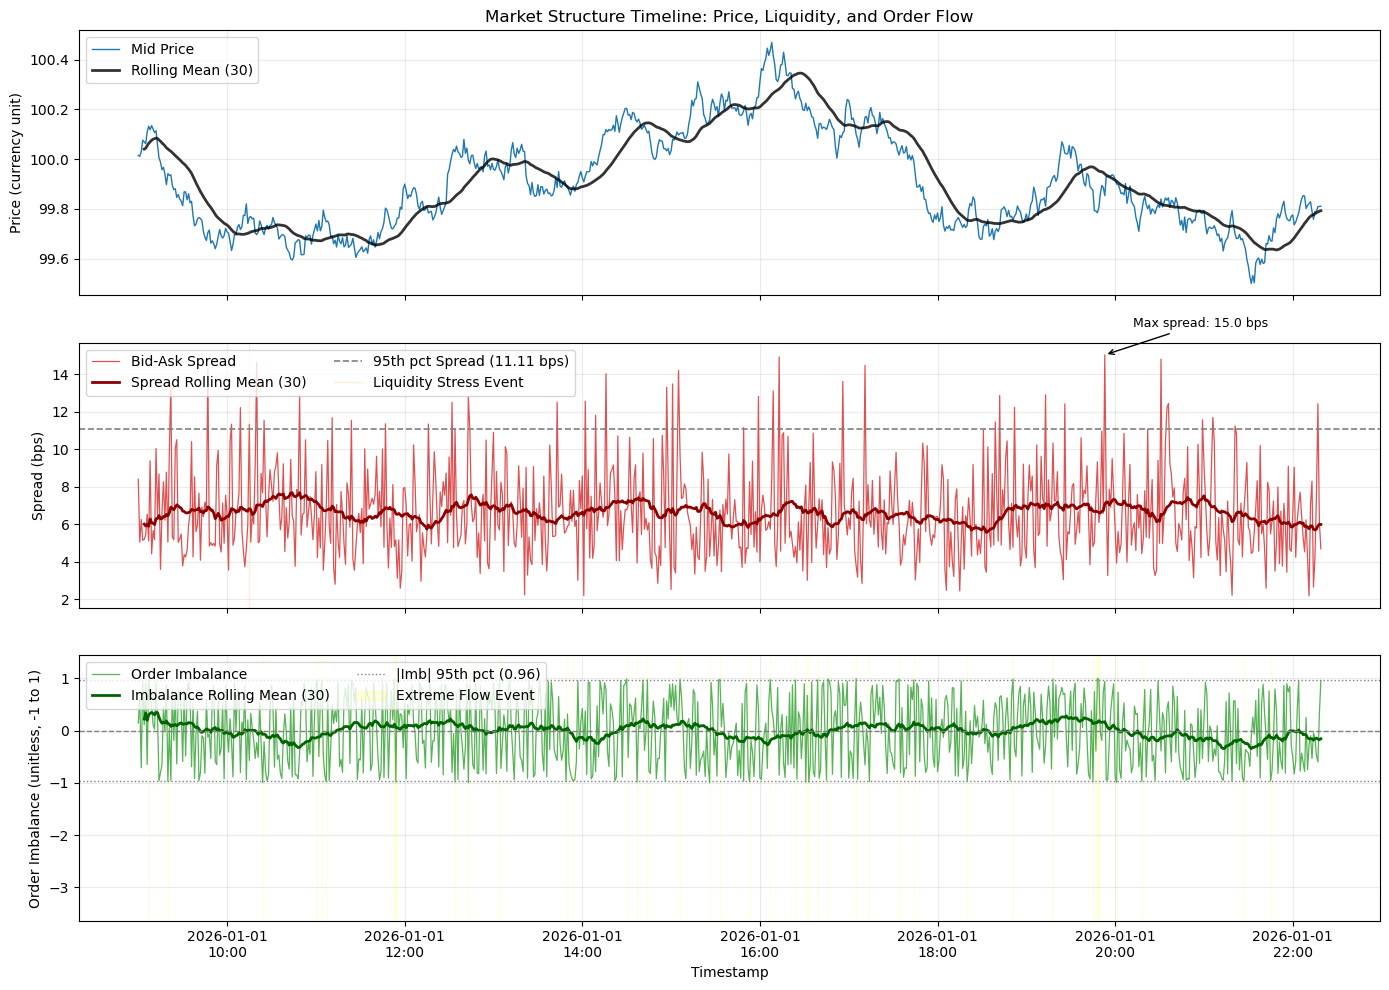

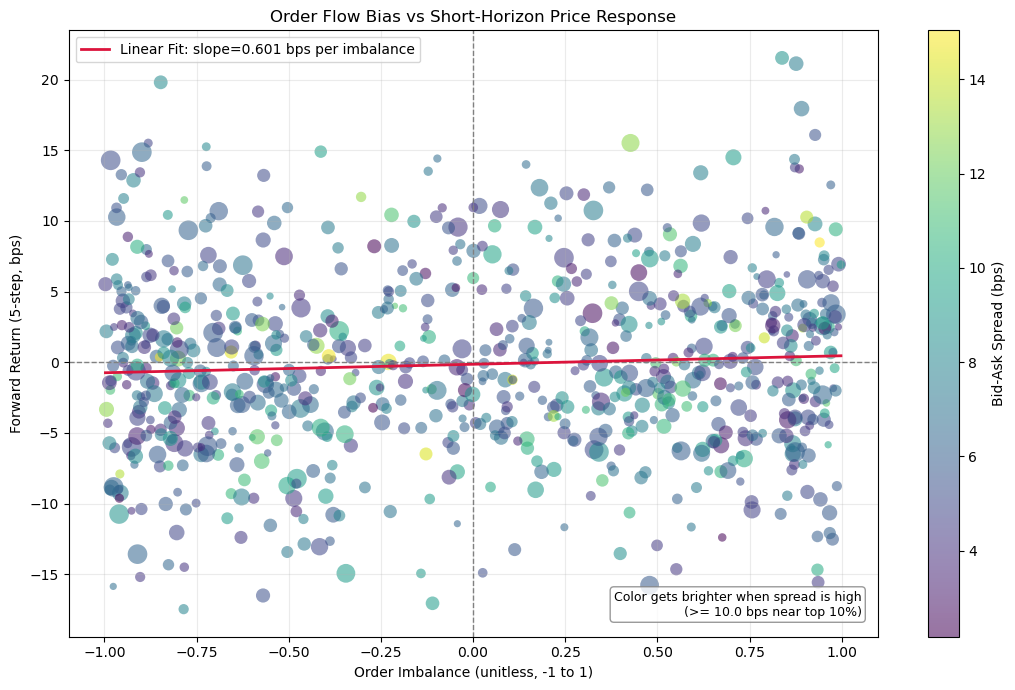

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 0) df が存在しない場合のみ最小ダミーデータを作成
required_cols = [
    "timestamp", "mid_price", "trade_price", "trade_size", "bid_ask_spread_bps",
    "bid_depth", "ask_depth", "signed_volume", "order_imbalance"
]

need_dummy = False
if "df" not in globals():
    need_dummy = True
elif not isinstance(df, pd.DataFrame):
    need_dummy = True
elif not set(required_cols).issubset(df.columns):
    need_dummy = True
elif len(df) == 0:
    need_dummy = True

if need_dummy:
    np.random.seed(42)
    n = 800
    ts = pd.date_range("2026-01-01 09:00:00", periods=n, freq="min")

    mid = 100 + np.cumsum(np.random.normal(0, 0.03, n))
    spread_bps = np.clip(np.random.lognormal(mean=1.8, sigma=0.35, size=n), 2, 80)
    trade_size = np.random.gamma(shape=2.0, scale=20.0, size=n)
    signed_volume = np.random.normal(0, 1.0, n) * trade_size
    bid_depth = np.clip(np.random.normal(900, 180, n), 50, None)
    ask_depth = np.clip(np.random.normal(880, 180, n), 50, None)

    raw_imb = signed_volume / (trade_size + 1e-9) + np.random.normal(0, 0.25, n)
    order_imbalance = np.tanh(raw_imb)

    # trade_price は mid_price 周辺 + スプレッド方向のずれ
    trade_price = mid * (1 + (0.08 * spread_bps / 1e4) * np.sign(signed_volume)) + np.random.normal(0, 0.01, n)

    df = pd.DataFrame({
        "timestamp": ts,
        "mid_price": mid,
        "trade_price": trade_price,
        "trade_size": trade_size,
        "bid_ask_spread_bps": spread_bps,
        "bid_depth": bid_depth,
        "ask_depth": ask_depth,
        "signed_volume": signed_volume,
        "order_imbalance": order_imbalance
    })

# 1) 前処理
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

for c in required_cols[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=required_cols[1:]).reset_index(drop=True)

# 派生特徴量
df["mid_ret_bps"] = df["mid_price"].pct_change() * 1e4
df["fwd_ret_5_bps"] = (df["mid_price"].shift(-5) / df["mid_price"] - 1.0) * 1e4
df["depth_total"] = df["bid_depth"] + df["ask_depth"]
df["depth_imbalance"] = (df["bid_depth"] - df["ask_depth"]) / (df["depth_total"] + 1e-9)

# rolling 窓（データ頻度に応じて調整）
win = 30
df["mid_ma"] = df["mid_price"].rolling(win, min_periods=5).mean()
df["spread_ma"] = df["bid_ask_spread_bps"].rolling(win, min_periods=5).mean()
df["imb_ma"] = df["order_imbalance"].rolling(win, min_periods=5).mean()

# イベント定義
spread_q95 = df["bid_ask_spread_bps"].quantile(0.95)
depth_q10 = df["depth_total"].quantile(0.10)
imb_q95 = df["order_imbalance"].abs().quantile(0.95)

stress_event = (df["bid_ask_spread_bps"] >= spread_q95) & (df["depth_total"] <= depth_q10)
flow_event = df["order_imbalance"].abs() >= imb_q95

# 2) 図1: 時系列レジーム図
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: 価格
axes[0].plot(df["timestamp"], df["mid_price"], lw=1.0, color="tab:blue", label="Mid Price")
axes[0].plot(df["timestamp"], df["mid_ma"], lw=2.0, color="black", alpha=0.8, label=f"Rolling Mean ({win})")
axes[0].set_ylabel("Price (currency unit)")
axes[0].set_title("Market Structure Timeline: Price, Liquidity, and Order Flow")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.25)

# Panel 2: スプレッド + ストレスイベント線
axes[1].plot(df["timestamp"], df["bid_ask_spread_bps"], lw=0.9, color="tab:red", alpha=0.8, label="Bid-Ask Spread")
axes[1].plot(df["timestamp"], df["spread_ma"], lw=2.0, color="darkred", label=f"Spread Rolling Mean ({win})")
axes[1].axhline(spread_q95, color="gray", ls="--", lw=1.2, label=f"95th pct Spread ({spread_q95:.2f} bps)")

stress_times = df.loc[stress_event, "timestamp"]
for i, t in enumerate(stress_times):
    axes[1].axvline(t, color="orange", alpha=0.18, lw=0.8, label="Liquidity Stress Event" if i == 0 else None)

axes[1].set_ylabel("Spread (bps)")
axes[1].legend(loc="upper left", ncol=2)
axes[1].grid(alpha=0.25)

# 最大スプレッド点に注釈
idx_max_spread = df["bid_ask_spread_bps"].idxmax()
x_ms = df.loc[idx_max_spread, "timestamp"]
y_ms = df.loc[idx_max_spread, "bid_ask_spread_bps"]
axes[1].annotate(
    f"Max spread: {y_ms:.1f} bps",
    xy=(x_ms, y_ms),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.0, color="black"),
    fontsize=9
)

# Panel 3: 注文フロー偏り
axes[2].plot(df["timestamp"], df["order_imbalance"], lw=0.9, color="tab:green", alpha=0.8, label="Order Imbalance")
axes[2].plot(df["timestamp"], df["imb_ma"], lw=2.0, color="darkgreen", label=f"Imbalance Rolling Mean ({win})")
axes[2].axhline(0, color="gray", ls="--", lw=1.0)
axes[2].axhline(imb_q95, color="gray", ls=":", lw=1.0, label=f"|Imb| 95th pct ({imb_q95:.2f})")
axes[2].axhline(-imb_q95, color="gray", ls=":", lw=1.0)

# フローイベントを背景ハイライト
axes[2].fill_between(
    df["timestamp"],
    -1.05, 1.05,
    where=flow_event.values,
    color="yellow",
    alpha=0.12,
    transform=axes[2].get_xaxis_transform(),
    label="Extreme Flow Event"
)

axes[2].set_ylabel("Order Imbalance (unitless, -1 to 1)")
axes[2].set_xlabel("Timestamp")
axes[2].legend(loc="upper left", ncol=2)
axes[2].grid(alpha=0.25)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.tight_layout()
plt.show()

# 3) 図2: 注文フロー偏り vs 将来リターン
plot_df = df.dropna(subset=["order_imbalance", "fwd_ret_5_bps", "bid_ask_spread_bps", "trade_size"]).copy()

fig, ax = plt.subplots(figsize=(11, 7))
size_scaled = 20 + 180 * (plot_df["trade_size"] / (plot_df["trade_size"].quantile(0.98) + 1e-9)).clip(0, 1)

sc = ax.scatter(
    plot_df["order_imbalance"],
    plot_df["fwd_ret_5_bps"],
    c=plot_df["bid_ask_spread_bps"],
    s=size_scaled,
    cmap="viridis",
    alpha=0.55,
    edgecolor="none"
)

ax.axvline(0, color="gray", ls="--", lw=1.0)
ax.axhline(0, color="gray", ls="--", lw=1.0)

# 解釈補助の単回帰線
x = plot_df["order_imbalance"].values
y = plot_df["fwd_ret_5_bps"].values
if len(plot_df) > 10:
    coef = np.polyfit(x, y, 1)
    xline = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    yline = coef[0] * xline + coef[1]
    ax.plot(xline, yline, color="crimson", lw=2.0, label=f"Linear Fit: slope={coef[0]:.3f} bps per imbalance")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Bid-Ask Spread (bps)")

ax.set_title("Order Flow Bias vs Short-Horizon Price Response")
ax.set_xlabel("Order Imbalance (unitless, -1 to 1)")
ax.set_ylabel("Forward Return (5-step, bps)")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)

high_spread_level = plot_df["bid_ask_spread_bps"].quantile(0.9)
ax.annotate(
    f"Color gets brighter when spread is high\n(>= {high_spread_level:.1f} bps near top 10%)",
    xy=(0.98, 0.03),
    xycoords="axes fraction",
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)

plt.tight_layout()
plt.show()

## 3. 読み方（マイクロストラクチャ観点）

- 図1（時系列レジーム図）
  スプレッド急拡大と depth 低下が同時に出る区間は、流動性悪化レジームの候補です。そこに `order_imbalance` の極端値が重なるなら、薄い板に片方向フローが当たり、価格が跳びやすい局面を示唆します。

- 図2（フロー偏り vs 将来リターン）
  回帰線の傾きが正で明瞭なら、注文フロー偏りが短期価格形成に効いている可能性があります。さらに高スプレッド色の点で傾向が強いなら、流動性が悪い局面ほど価格インパクトが増幅される、と解釈できます。

## 短期リターン予測: 設計上の落とし穴とベースライン

### 1) この問題設定の主な落とし穴
- **リーク**: `future_mid_return_*` を特徴量に混ぜる、あるいは split 前に全期間で標準化/外れ値処理をすると情報漏洩になる
- **内生性**: `signed_volume` や `order_imbalance` は価格変化と同時決定されやすく、単純回帰の係数解釈は因果にならない
- **多重共線性**: `signed_volume` と `order_imbalance`、`spread_bps` と `realized_vol_5min` が高相関になりやすい
- **非定常性**: 市場状態が時間で変わるため、古いデータが将来に効かない（係数/関係がドリフト）
- **Regime change**: ボラ急拡大や流動性低下で予測関係が切り替わる
- **外れ値とスケーリング**: マイクロストラクチャ系は裾が重く、通常の平均/分散スケーリングが不安定になりやすい

### 2) ベースラインモデル2案
- **案A: Ridge回帰（L2）**
  - 長所: 多重共線性に強い、係数が比較的安定、実装が軽い
  - 短所: 線形前提が強く、regime切替や非線形を捉えにくい
  - 目的関数:

$$
\min_{\beta} \sum_t (y_t - x_t^\top\beta)^2 + \lambda \lVert\beta\rVert_2^2
$$

- **案B: Huber回帰（ロバスト線形）**
  - 長所: 外れ値に頑健、線形モデルの解釈性を保ちやすい
  - 短所: 非線形そのものは表現しづらく、パラメータ感度がある

### 3) 学習・検証の切り方（提案）
- 時系列順に `train -> gap(embargo) -> validation` を使う
- `gap` は少なくとも予測ホライズン（ここでは 5 ステップ）以上
- 前処理（外れ値クリップ、スケーリング）は **trainでfitし、validationへ適用のみ**
- validation を前半/後半に分けて指標比較し、regime変化の兆候を確認

In [2]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 0) df が無い場合のみ最小ダミー作成
# =========================
required_cols = [
    "timestamp", "mid_price", "future_mid_return_1min", "future_mid_return_5min",
    "spread_bps", "depth_total", "signed_volume", "order_imbalance",
    "realized_vol_5min", "lagged_return_1min"
]

need_dummy = False
if "df" not in globals():
    need_dummy = True
elif not isinstance(df, pd.DataFrame):
    need_dummy = True
elif not set(required_cols).issubset(df.columns):
    need_dummy = True
elif len(df) == 0:
    need_dummy = True

if need_dummy:
    np.random.seed(7)
    n = 1500
    ts = pd.date_range("2026-01-01 09:00:00", periods=n, freq="min")

    # ダミーの mid と microstructure 特徴
    mid = 100 + np.cumsum(np.random.normal(0, 0.02, n))
    spread_bps = np.clip(np.random.lognormal(mean=1.5, sigma=0.45, size=n), 1.5, 120)
    depth_total = np.clip(np.random.normal(2500, 600, n), 100, None)
    signed_volume = np.random.normal(0, 80, n)
    order_imbalance = np.tanh(np.random.normal(0, 0.9, n))

    # 1分リターンの疑似生成（説明変数と弱く関係）
    ret_1 = (
        0.020 * order_imbalance
        - 0.006 * (spread_bps / 10)
        + 0.004 * (signed_volume / 100)
        + np.random.normal(0, 0.06, n)
    )
    ret_1 = pd.Series(ret_1)

    lagged_return_1min = ret_1.shift(1).fillna(0.0).values
    realized_vol_5min = ret_1.rolling(5).std().fillna(ret_1.std()).values

    # future return は t 時点の将来値として配置
    future_mid_return_1min = ret_1.shift(-1)
    future_mid_return_5min = ret_1.rolling(5).sum().shift(-5)

    df = pd.DataFrame({
        "timestamp": ts,
        "mid_price": mid,
        "future_mid_return_1min": future_mid_return_1min,
        "future_mid_return_5min": future_mid_return_5min,
        "spread_bps": spread_bps,
        "depth_total": depth_total,
        "signed_volume": signed_volume,
        "order_imbalance": order_imbalance,
        "realized_vol_5min": realized_vol_5min,
        "lagged_return_1min": lagged_return_1min,
    })

# =========================
# 1) 前処理と時間整合性
# =========================
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for c in required_cols[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 予測時点 t の特徴量で、t+1min / t+5min リターンを予測する前提
feature_cols = [
    "spread_bps", "depth_total", "signed_volume", "order_imbalance",
    "realized_vol_5min", "lagged_return_1min"
]
target_cols = ["future_mid_return_1min", "future_mid_return_5min"]

model_df = (
    df[["timestamp"] + feature_cols + target_cols]
    .dropna()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# =========================
# 2) train/validation split（時系列順 + embargo）
# =========================
n = len(model_df)
train_end = int(n * 0.7)
embargo = 5  # 5ステップ先リターンとの重なり回避
val_start = train_end + embargo

if val_start >= n - 30:
    raise ValueError("データが少なすぎます。split後のvalidationを確保できません。")

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[val_start:].copy()

# 外れ値クリップは train 分位点で実施（リーク回避）
q_low = train_df[feature_cols].quantile(0.01)
q_high = train_df[feature_cols].quantile(0.99)

X_train = train_df[feature_cols].clip(lower=q_low, upper=q_high, axis=1)
X_val = val_df[feature_cols].clip(lower=q_low, upper=q_high, axis=1)

# =========================
# 3) ベースライン2モデル
# =========================
ridge_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=1.0, random_state=42))
])

huber_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", HuberRegressor(epsilon=1.35, alpha=0.0001))
])

models = {
    "Ridge": ridge_model,
    "Huber": huber_model,
}

# =========================
# 4) 評価（MAE / RMSE / Directional Accuracy / IC）
# =========================
records = []

for target in target_cols:
    y_train = train_df[target].values
    y_val = val_df[target].values

    # ゼロ予測ベースライン
    y0 = np.zeros_like(y_val)
    records.append({
        "target": target,
        "model": "ZeroBaseline",
        "MAE": mean_absolute_error(y_val, y0),
        "RMSE": np.sqrt(mean_squared_error(y_val, y0)),
        "DirectionalAcc": np.mean(np.sign(y_val) == np.sign(y0)),
        "IC(Pearson)": np.nan,
    })

    for name, mdl in models.items():
        mdl.fit(X_train, y_train)
        pred = mdl.predict(X_val)

        ic = np.corrcoef(pred, y_val)[0, 1] if np.std(pred) > 0 and np.std(y_val) > 0 else np.nan
        records.append({
            "target": target,
            "model": name,
            "MAE": mean_absolute_error(y_val, pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
            "DirectionalAcc": np.mean(np.sign(y_val) == np.sign(pred)),
            "IC(Pearson)": ic,
        })

result_df = pd.DataFrame(records).sort_values(["target", "RMSE", "MAE"]).reset_index(drop=True)
print("=== Holdout Validation Metrics (time-ordered split) ===")
display(result_df)

# =========================
# 5) regime change 簡易チェック: validation前半/後半で性能比較
# =========================
print("\n=== Regime Check (validation first half vs second half) ===")

mid_idx = len(val_df) // 2
X_val_1 = X_val.iloc[:mid_idx]
X_val_2 = X_val.iloc[mid_idx:]

for target in target_cols:
    y_train = train_df[target].values
    y_val_1 = val_df[target].iloc[:mid_idx].values
    y_val_2 = val_df[target].iloc[mid_idx:].values

    ridge_model.fit(X_train, y_train)
    p1 = ridge_model.predict(X_val_1)
    p2 = ridge_model.predict(X_val_2)

    rmse_1 = np.sqrt(mean_squared_error(y_val_1, p1))
    rmse_2 = np.sqrt(mean_squared_error(y_val_2, p2))

    print(f"{target}: Ridge RMSE first_half={rmse_1:.6f}, second_half={rmse_2:.6f}")

# =========================
# 6) まず最初に試すべき現実的な一案
# =========================
print("\n推奨スタート案:")
print("1) target=future_mid_return_5min を主対象")
print("2) Ridge + RobustScaler")
print("3) train=先頭70%, embargo=5, validation=後半30%")
print("4) MAE/RMSE/IC と validation前後半のRMSE差を毎回確認")

=== Holdout Validation Metrics (time-ordered split) ===


,target,model,MAE,RMSE,DirectionalAcc,IC(Pearson)
0,future_mid_return_1min,ZeroBaseline,0.049562,0.062272,0.000000,NaN
1,future_mid_return_1min,Ridge,0.050141,0.062886,0.486486,-0.037017
2,future_mid_return_1min,Huber,0.050170,0.062929,0.477477,-0.037466
3,future_mid_return_5min,ZeroBaseline,0.127898,0.155697,0.000000,NaN
4,future_mid_return_5min,Huber,0.128337,0.156212,0.488739,0.060139
5,future_mid_return_5min,Ridge,0.128537,0.156412,0.493243,0.022869



=== Regime Check (validation first half vs second half) ===
future_mid_return_1min: Ridge RMSE first_half=0.062166, second_half=0.063597
future_mid_return_5min: Ridge RMSE first_half=0.157926, second_half=0.154884

推奨スタート案:
1) target=future_mid_return_5min を主対象
2) Ridge + RobustScaler
3) train=先頭70%, embargo=5, validation=後半30%
4) MAE/RMSE/IC と validation前後半のRMSE差を毎回確認


### 補足（この実装の読み方）
- 係数の因果解釈はしない（内生性があるため）
- 指標は単純精度だけでなく、`IC(Pearson)` と validation前半/後半の差で安定性を見る
- もし前半と後半で性能差が大きい場合は、固定学習ではなく rolling/expanding 再学習へ進む

## 戦略パフォーマンス可視化（投資家/PM向け）

### 1. 作るべき図の提案（3案）
- **案A（最重要）: 累積リターン + ドローダウン + ベンチマーク比較**
  - 何が分かるか: 「どれだけ増えたか」だけでなく、「どれだけ痛んだか」を同時に把握できる
- **案B（最重要）: Turnover と Gross Exposure の時系列モニタ**
  - 何が分かるか: 実装コスト圧力・レバレッジ依存・運用負荷の上昇局面を把握できる
- **案C（候補）: リターン分布（strategy / benchmark / excess）**
  - 何が分かるか: 歪度・裾の重さ・下方リスクを直感的に比較できる

### 2. 今回実装する2案
- **案A**: 投資家説明で最初に必要な「成長と痛み」の全体像を同時に見せられるため
- **案B**: 累積リターンだけでは見えない「その成績をどう作ったか（回転率・エクスポージャ）」を補完できるため

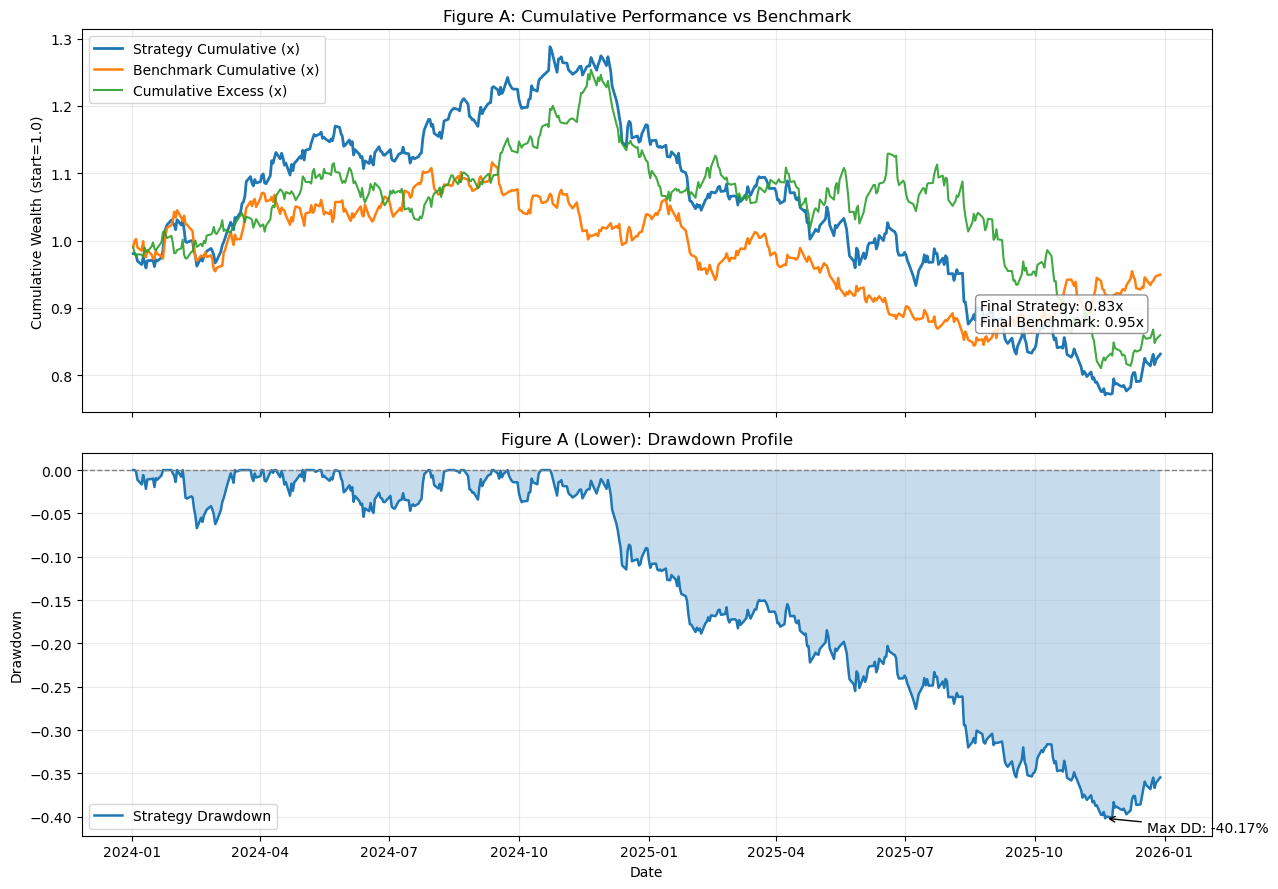

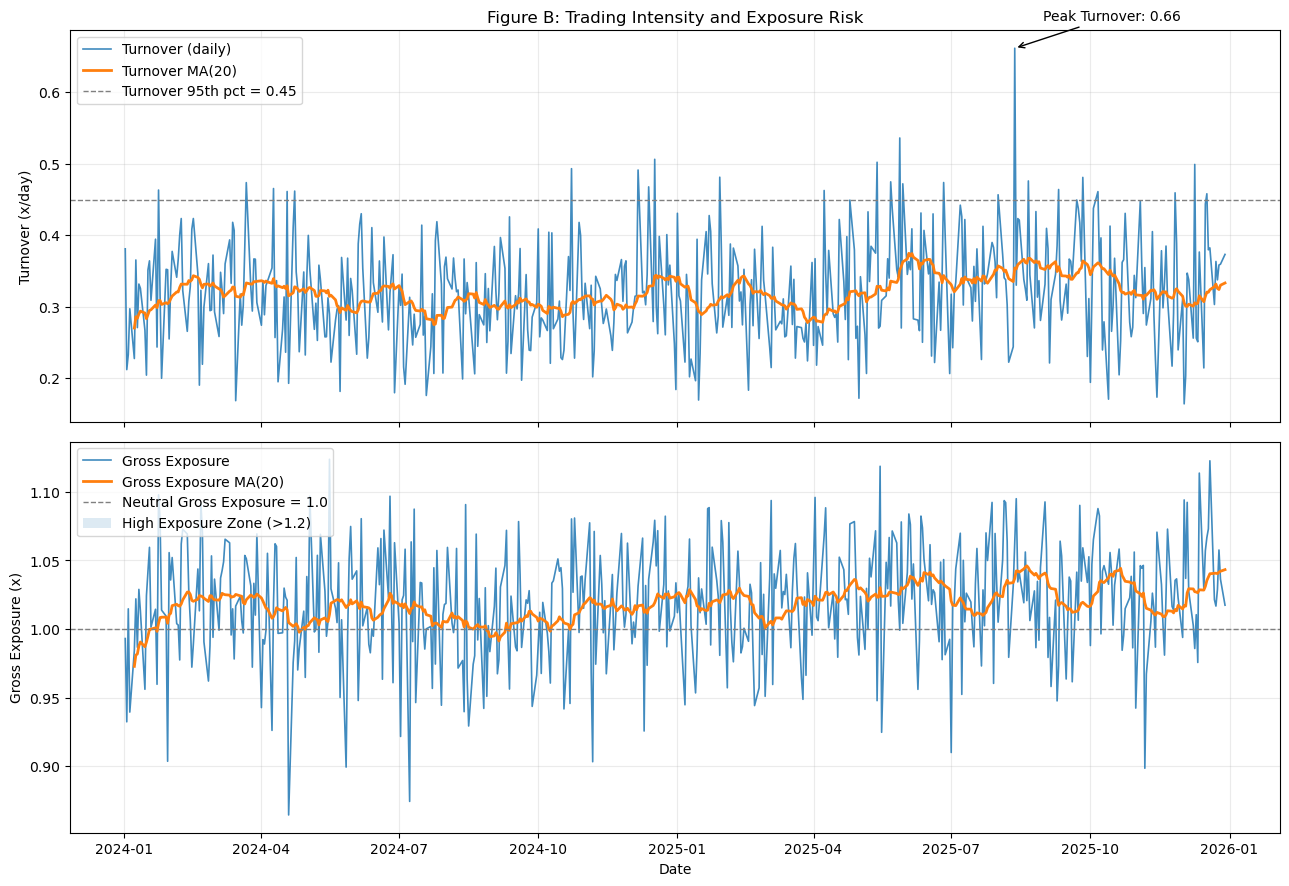

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================
# 0) df が無い場合のみ最小ダミーデータ作成
# =========================
required_cols = ["date", "strategy_return", "benchmark_return", "turnover", "gross_exposure"]

need_dummy = False
if "df" not in globals():
    need_dummy = True
elif not isinstance(df, pd.DataFrame):
    need_dummy = True
elif not set(required_cols).issubset(df.columns):
    need_dummy = True
elif len(df) == 0:
    need_dummy = True

if need_dummy:
    np.random.seed(123)
    n = 520
    dates = pd.bdate_range("2024-01-02", periods=n)

    # 2つのレジームを持つ簡易ダミー
    regime = np.where(np.arange(n) < int(n * 0.65), 0, 1)
    vol = np.where(regime == 0, 0.007, 0.012)
    alpha = np.where(regime == 0, 0.00035, -0.00005)

    benchmark_return = np.random.normal(0.00020, 0.0085, n)
    strategy_return = alpha + 0.55 * benchmark_return + np.random.normal(0, vol, n)

    # turnover は変動率が高い局面で上がりやすく設定
    turnover = np.clip(0.25 + 9.0 * np.abs(strategy_return) + np.random.normal(0, 0.05, n), 0.02, 1.80)

    # gross_exposure は 1 を中心に上下
    gross_exposure = np.clip(1.0 + 2.2 * pd.Series(strategy_return).rolling(5).std().fillna(0.0).values + np.random.normal(0, 0.04, n), 0.65, 1.85)

    df = pd.DataFrame({
        "date": dates,
        "strategy_return": strategy_return,
        "benchmark_return": benchmark_return,
        "turnover": turnover,
        "gross_exposure": gross_exposure,
    })

# =========================
# 1) 前処理
# =========================
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for c in required_cols[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

plot_df = (
    df[required_cols]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

# =========================
# 2) 指標作成
# =========================
plot_df["cum_strategy"] = (1.0 + plot_df["strategy_return"]).cumprod()
plot_df["cum_benchmark"] = (1.0 + plot_df["benchmark_return"]).cumprod()
plot_df["cum_excess"] = (1.0 + (plot_df["strategy_return"] - plot_df["benchmark_return"])).cumprod()

roll_max = plot_df["cum_strategy"].cummax()
plot_df["drawdown"] = plot_df["cum_strategy"] / roll_max - 1.0

plot_df["turnover_ma20"] = plot_df["turnover"].rolling(20, min_periods=5).mean()
plot_df["gross_exposure_ma20"] = plot_df["gross_exposure"].rolling(20, min_periods=5).mean()

max_dd_idx = plot_df["drawdown"].idxmin()
max_dd_date = plot_df.loc[max_dd_idx, "date"]
max_dd_val = plot_df.loc[max_dd_idx, "drawdown"]

turnover_q95 = plot_df["turnover"].quantile(0.95)
max_to_idx = plot_df["turnover"].idxmax()
max_to_date = plot_df.loc[max_to_idx, "date"]
max_to_val = plot_df.loc[max_to_idx, "turnover"]

# =========================
# 図A: 累積リターン + ドローダウン + ベンチマーク
# =========================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax1.plot(plot_df["date"], plot_df["cum_strategy"], label="Strategy Cumulative (x)", lw=2.0)
ax1.plot(plot_df["date"], plot_df["cum_benchmark"], label="Benchmark Cumulative (x)", lw=1.8)
ax1.plot(plot_df["date"], plot_df["cum_excess"], label="Cumulative Excess (x)", lw=1.5, alpha=0.9)
ax1.set_title("Figure A: Cumulative Performance vs Benchmark")
ax1.set_ylabel("Cumulative Wealth (start=1.0)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.25)

# 期末値注釈
final_s = plot_df["cum_strategy"].iloc[-1]
final_b = plot_df["cum_benchmark"].iloc[-1]
ax1.annotate(
    f"Final Strategy: {final_s:.2f}x\nFinal Benchmark: {final_b:.2f}x",
    xy=(plot_df["date"].iloc[-1], final_s),
    xytext=(-130, 20),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85),
)

ax2.plot(plot_df["date"], plot_df["drawdown"], label="Strategy Drawdown", lw=1.8)
ax2.fill_between(plot_df["date"], plot_df["drawdown"], 0, alpha=0.25)
ax2.axhline(0, color="gray", ls="--", lw=1.0)
ax2.set_title("Figure A (Lower): Drawdown Profile")
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.25)

ax2.annotate(
    f"Max DD: {max_dd_val:.2%}",
    xy=(max_dd_date, max_dd_val),
    xytext=(30, -10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.0),
)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()

# =========================
# 図B: Turnover / Gross Exposure モニタ
# =========================
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax3.plot(plot_df["date"], plot_df["turnover"], label="Turnover (daily)", lw=1.2, alpha=0.85)
ax3.plot(plot_df["date"], plot_df["turnover_ma20"], label="Turnover MA(20)", lw=2.0)
ax3.axhline(turnover_q95, color="gray", ls="--", lw=1.0, label=f"Turnover 95th pct = {turnover_q95:.2f}")
ax3.set_title("Figure B: Trading Intensity and Exposure Risk")
ax3.set_ylabel("Turnover (x/day)")
ax3.legend(loc="upper left")
ax3.grid(alpha=0.25)

ax3.annotate(
    f"Peak Turnover: {max_to_val:.2f}",
    xy=(max_to_date, max_to_val),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.0),
)

ax4.plot(plot_df["date"], plot_df["gross_exposure"], label="Gross Exposure", lw=1.2, alpha=0.85)
ax4.plot(plot_df["date"], plot_df["gross_exposure_ma20"], label="Gross Exposure MA(20)", lw=2.0)
ax4.axhline(1.0, color="gray", ls="--", lw=1.0, label="Neutral Gross Exposure = 1.0")

# 1.2超を薄くハイライト
high_expo = plot_df["gross_exposure"] > 1.2
ax4.fill_between(
    plot_df["date"],
    plot_df["gross_exposure"],
    1.2,
    where=high_expo,
    alpha=0.15,
    label="High Exposure Zone (>1.2)",
)

ax4.set_ylabel("Gross Exposure (x)")
ax4.set_xlabel("Date")
ax4.legend(loc="upper left")
ax4.grid(alpha=0.25)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

### 各図の読み方（何を示し、どの弱点/リスクを補足するか）
- **Figure A（累積 + ドローダウン + ベンチマーク）**
  - 示すもの: 絶対成績、相対成績、最大損失局面の3点
  - 補足する弱点/リスク: 累積リターン1本では隠れる「下落耐性の弱さ」「ベンチマーク依存」を可視化

- **Figure B（Turnover + Gross Exposure）**
  - 示すもの: どれだけ売買回転で成績を作っているか、どれだけリスクを取りに行っているか
  - 補足する弱点/リスク: 高回転に伴うコスト悪化リスク、過大エクスポージャによるボラ増幅リスクを把握

- **次に検討する候補（未実装）**
  - strategy / benchmark / excess の分布図（ヒストグラム）を追加すると、裾リスクと非対称性の説明がしやすくなります。

## 戦略パフォーマンス可視化（追加版）

### 1. 作るべき図（3案）
- **案A: 累積リターン + ベンチマーク + ドローダウン（2段）**
  - 成果と痛みを同時に示せるため、最初に見るべき図
- **案B: Turnover と Gross Exposure の運用負荷モニタ（2段）**
  - 高回転・高エクスポージャ依存かを把握できる図
- **案C: リターン分布（strategy / benchmark / excess）**
  - 裾リスク、歪み、相対優位の安定性を把握できる図

### 2. 今回実装する最重要2案
- **実装1: 案A**（投資家説明で最重要: リターンとDDは必須）
- **実装2: 案C**（累積では見えない下方裾リスクを補足できる）

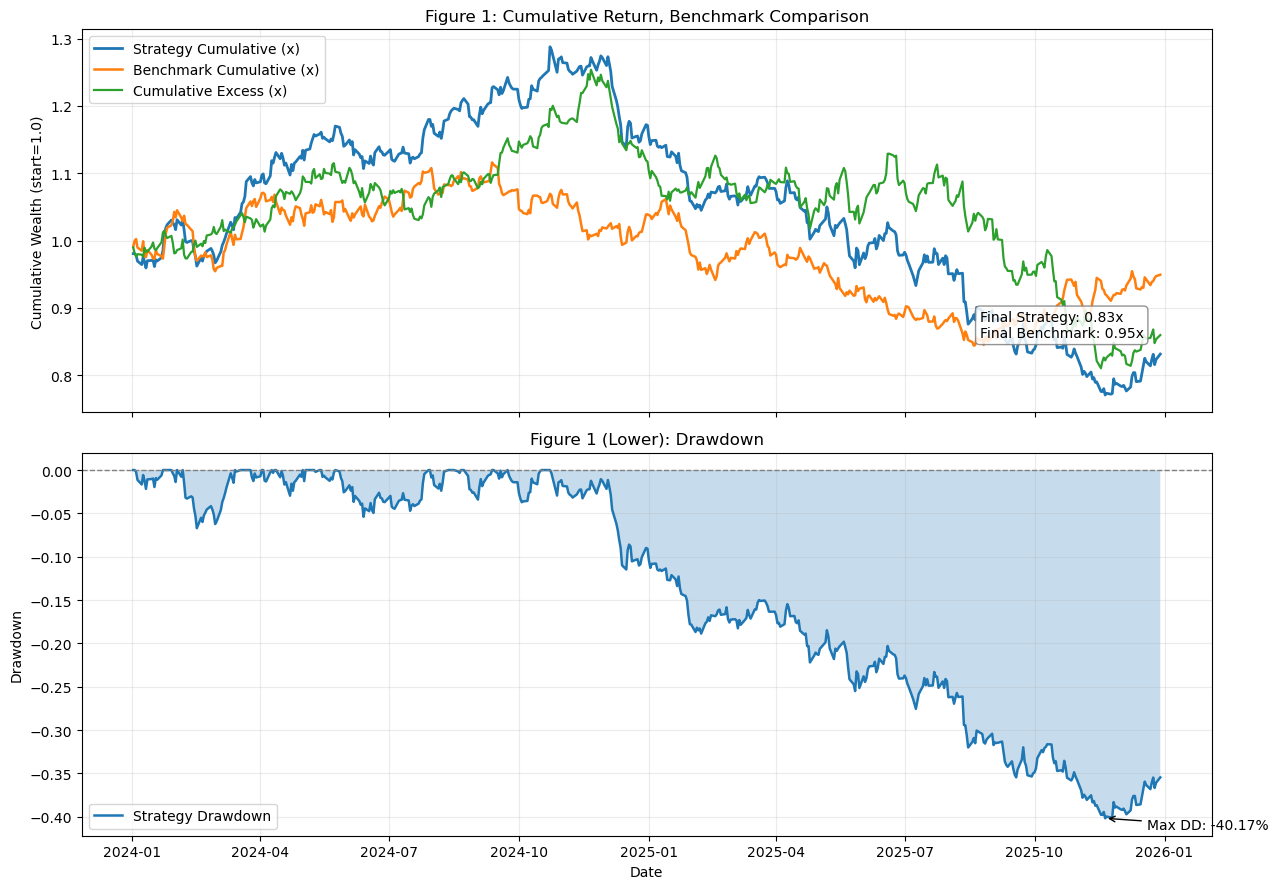

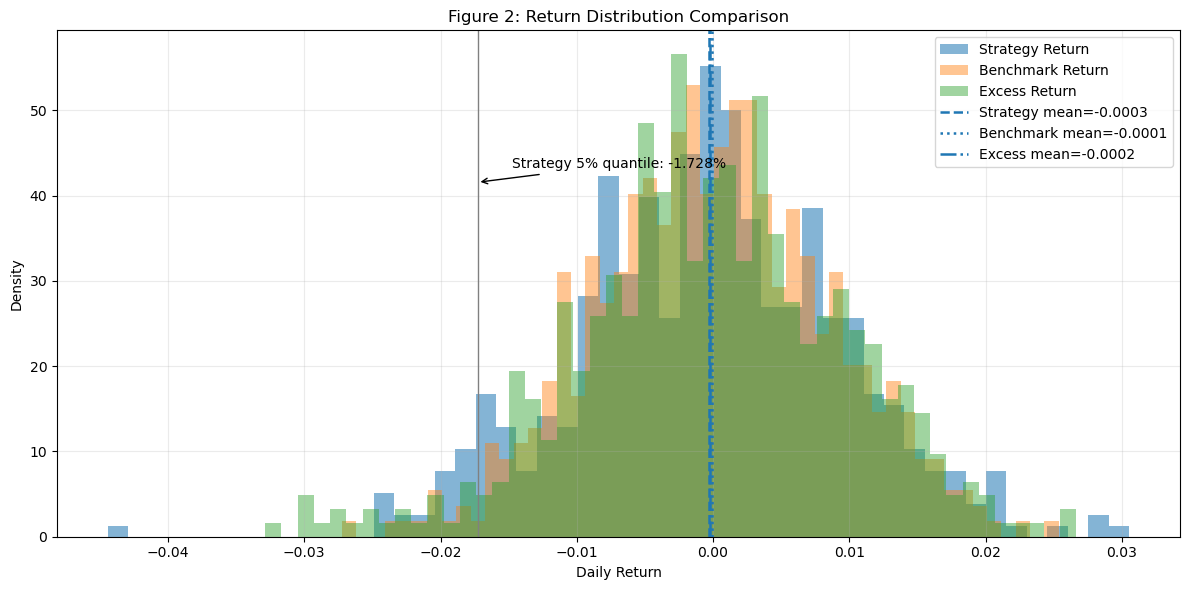

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 0) df が存在しない場合のみ最小ダミーデータ生成
required_cols = ["date", "strategy_return", "benchmark_return", "turnover", "gross_exposure"]

need_dummy = False
if "df" not in globals():
    need_dummy = True
elif not isinstance(df, pd.DataFrame):
    need_dummy = True
elif not set(required_cols).issubset(df.columns):
    need_dummy = True
elif len(df) == 0:
    need_dummy = True

if need_dummy:
    np.random.seed(2026)
    n = 500
    date = pd.bdate_range("2024-01-01", periods=n)
    benchmark_return = np.random.normal(0.0002, 0.009, n)
    strategy_return = 0.00015 + 0.6 * benchmark_return + np.random.normal(0, 0.010, n)
    turnover = np.clip(0.25 + 6.0 * np.abs(strategy_return) + np.random.normal(0, 0.04, n), 0.02, 1.8)
    gross_exposure = np.clip(1.0 + np.random.normal(0, 0.06, n), 0.6, 1.8)

    df = pd.DataFrame({
        "date": date,
        "strategy_return": strategy_return,
        "benchmark_return": benchmark_return,
        "turnover": turnover,
        "gross_exposure": gross_exposure,
    })

# 1) 前処理
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for c in required_cols[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

plot_df = (
    df[required_cols]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

# 2) 指標
plot_df["excess_return"] = plot_df["strategy_return"] - plot_df["benchmark_return"]
plot_df["cum_strategy"] = (1 + plot_df["strategy_return"]).cumprod()
plot_df["cum_benchmark"] = (1 + plot_df["benchmark_return"]).cumprod()
plot_df["cum_excess"] = (1 + plot_df["excess_return"]).cumprod()
plot_df["drawdown"] = plot_df["cum_strategy"] / plot_df["cum_strategy"].cummax() - 1

mdd_idx = plot_df["drawdown"].idxmin()
mdd_date = plot_df.loc[mdd_idx, "date"]
mdd_val = plot_df.loc[mdd_idx, "drawdown"]

# 3) 図1: 累積 + ベンチマーク + ドローダウン
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax1.plot(plot_df["date"], plot_df["cum_strategy"], lw=2.0, label="Strategy Cumulative (x)")
ax1.plot(plot_df["date"], plot_df["cum_benchmark"], lw=1.8, label="Benchmark Cumulative (x)")
ax1.plot(plot_df["date"], plot_df["cum_excess"], lw=1.6, label="Cumulative Excess (x)")
ax1.set_title("Figure 1: Cumulative Return, Benchmark Comparison")
ax1.set_ylabel("Cumulative Wealth (start=1.0)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.25)

last_date = plot_df["date"].iloc[-1]
ax1.annotate(
    f"Final Strategy: {plot_df['cum_strategy'].iloc[-1]:.2f}x\nFinal Benchmark: {plot_df['cum_benchmark'].iloc[-1]:.2f}x",
    xy=(last_date, plot_df["cum_strategy"].iloc[-1]),
    xytext=(-130, 12),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85),
)

ax2.plot(plot_df["date"], plot_df["drawdown"], lw=1.8, label="Strategy Drawdown")
ax2.fill_between(plot_df["date"], plot_df["drawdown"], 0, alpha=0.25)
ax2.axhline(0, lw=1.0, ls="--", color="gray")
ax2.set_title("Figure 1 (Lower): Drawdown")
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.25)
ax2.annotate(
    f"Max DD: {mdd_val:.2%}",
    xy=(mdd_date, mdd_val),
    xytext=(30, -8),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.0),
)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()

# 4) 図2: リターン分布比較（strategy / benchmark / excess）
fig, ax = plt.subplots(figsize=(12, 6))

bins = 50
ax.hist(plot_df["strategy_return"], bins=bins, alpha=0.55, density=True, label="Strategy Return")
ax.hist(plot_df["benchmark_return"], bins=bins, alpha=0.45, density=True, label="Benchmark Return")
ax.hist(plot_df["excess_return"], bins=bins, alpha=0.45, density=True, label="Excess Return")

s_mean = plot_df["strategy_return"].mean()
b_mean = plot_df["benchmark_return"].mean()
e_mean = plot_df["excess_return"].mean()

ax.axvline(s_mean, lw=1.8, ls="--", label=f"Strategy mean={s_mean:.4f}")
ax.axvline(b_mean, lw=1.8, ls=":", label=f"Benchmark mean={b_mean:.4f}")
ax.axvline(e_mean, lw=1.8, ls="-.", label=f"Excess mean={e_mean:.4f}")

# 左裾5%閾値の注釈
left5 = np.quantile(plot_df["strategy_return"], 0.05)
ax.axvline(left5, lw=1.0, color="gray")
ax.annotate(
    f"Strategy 5% quantile: {left5:.3%}",
    xy=(left5, ax.get_ylim()[1] * 0.7),
    xytext=(25, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1.0),
)

ax.set_title("Figure 2: Return Distribution Comparison")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3. 各図の読み方（簡潔版）
- **Figure 1（累積+DD）**
  - 何を示すか: 絶対成績、ベンチマーク対比、最大損失局面
  - 補足するリスク: 累積一本では見えない「下落耐性の弱さ」「回復の遅さ」

- **Figure 2（分布比較）**
  - 何を示すか: 平均だけでなく、ばらつき・左裾（下方リスク）・excessの安定性
  - 補足するリスク: 極端損失が多い戦略や、平均は高くても再現性が低い戦略を見抜ける

- **補足**
  - Turnover / Gross Exposure は既存の Figure B と組み合わせると、成績の背景（コスト・リスクテイク）をより説明しやすくなります。